<a href="https://colab.research.google.com/github/YueFong/2011-Alcal-a-Fdez-A-Fuzzy-Association-Rule-Based-Classification-Model-for-/blob/master/KDD99.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
import os
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.utils import np_utils, plot_model
from keras.datasets import mnist
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.utils import get_file

In [ ]:
try:
    path = get_file('kddcup.data_10_percent.gz', origin='http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz')
except:
    print('Error downloading')
    raise

print(path)

df = pd.read_csv(path, header=None)
print("Read {} rows.".format(len(df)))
df.dropna(inplace=True,axis=1)
df.columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'outcome'
]

pd.set_option('display.max_columns', 5)
pd.set_option('display.max_rows', 5)
# display 5 rows
display(df[0:5])

2146304/2144903 [==============================] - 1s 0us/step
/root/.keras/datasets/kddcup.data_10_percent.gz
Read 494021 rows.


,duration,protocol_type,...,dst_host_srv_rerror_rate,outcome
0,0,tcp,...,0.0,normal.
1,0,tcp,...,0.0,normal.
2,0,tcp,...,0.0,normal.
3,0,tcp,...,0.0,normal.
4,0,tcp,...,0.0,normal.


Analyzing a Dataset


Before we preprocess the KDD99 dataset let's have a look at the individual columns and distributions. You can use the following script to give a high-level overview of how a dataset appears.

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn import metrics
from scipy.stats import zscore

def expand_categories(values):
    result = []
    s = values.value_counts()
    t = float(len(values))
    for v in s.index:
        result.append("{}:{}%".format(v,round(100*(s[v]/t),2)))
    return "[{}]".format(",".join(result))

def analyze(df):
    print()
    cols = df.columns.values
    total = float(len(df))

    print("{} rows".format(int(total)))
    for col in cols:
        uniques = df[col].unique()
        unique_count = len(uniques)
        if unique_count>100:
            print("** {}:{} ({}%)".format(col,unique_count,int(((unique_count)/total)*100)))
        else:
            print("** {}:{}".format(col,expand_categories(df[col])))
            expand_categories(df[col])

The analysis looks at how many unique values are present. For example, duration, which is a numeric value, has 2495 unique values, and there is a 0% overlap. A text/categorical value such as protocol_type only has a few unique values, and the program shows the percentages of each. Columns with a large number of unique values do not have their item counts shown to save display space.

In [ ]:
# Analyze KDD-99
analyze(df)


494021 rows
** duration:2495 (0%)
** protocol_type:[icmp:57.41%,tcp:38.47%,udp:4.12%]
** service:[ecr_i:56.96%,private:22.45%,http:13.01%,smtp:1.97%,other:1.46%,domain_u:1.19%,ftp_data:0.96%,eco_i:0.33%,ftp:0.16%,finger:0.14%,urp_i:0.11%,telnet:0.1%,ntp_u:0.08%,auth:0.07%,pop_3:0.04%,time:0.03%,csnet_ns:0.03%,remote_job:0.02%,imap4:0.02%,gopher:0.02%,discard:0.02%,domain:0.02%,systat:0.02%,iso_tsap:0.02%,echo:0.02%,shell:0.02%,rje:0.02%,sql_net:0.02%,whois:0.02%,printer:0.02%,nntp:0.02%,courier:0.02%,mtp:0.02%,netbios_ssn:0.02%,sunrpc:0.02%,uucp:0.02%,vmnet:0.02%,uucp_path:0.02%,klogin:0.02%,bgp:0.02%,nnsp:0.02%,ssh:0.02%,supdup:0.02%,login:0.02%,hostnames:0.02%,efs:0.02%,daytime:0.02%,netbios_ns:0.02%,link:0.02%,ldap:0.02%,pop_2:0.02%,http_443:0.02%,netbios_dgm:0.02%,exec:0.02%,kshell:0.02%,name:0.02%,ctf:0.02%,netstat:0.02%,Z39_50:0.02%,IRC:0.01%,urh_i:0.0%,X11:0.0%,tim_i:0.0%,pm_dump:0.0%,red_i:0.0%,tftp_u:0.0%]
** flag:[SF:76.6%,S0:17.61%,REJ:5.44%,RSTR:0.18%,RSTO:0.12%,SH:0.02%,S

Encode the feature vector


We use the same two functions provided earlier to preprocess the data. The first encodes Z-Scores, and the second creates dummy variables from categorical columns.

In [ ]:
# Encode a numeric column as zscores
def encode_numeric_zscore(df, name, mean=None, sd=None):
    if mean is None:
        mean = df[name].mean()

    if sd is None:
        sd = df[name].std()

    df[name] = (df[name] - mean) / sd

# Encode text values to dummy variables(i.e. [1,0,0],
# [0,1,0],[0,0,1] for red,green,blue)
def encode_text_dummy(df, name):
    dummies = pd.get_dummies(df[name])
    for x in dummies.columns:
        dummy_name = f"{name}-{x}"
        df[dummy_name] = dummies[x]
    df.drop(name, axis=1, inplace=True)

Again, just as we did for anomaly detection, we preprocess the data set. We convert all numeric values to Z-Score, and we translate all categorical to dummy variables.

In [ ]:
# Now encode the feature vector

encode_numeric_zscore(df, 'duration')
encode_text_dummy(df, 'protocol_type')
encode_text_dummy(df, 'service')
encode_text_dummy(df, 'flag')
encode_numeric_zscore(df, 'src_bytes')
encode_numeric_zscore(df, 'dst_bytes')
encode_text_dummy(df, 'land')
encode_numeric_zscore(df, 'wrong_fragment')
encode_numeric_zscore(df, 'urgent')
encode_numeric_zscore(df, 'hot')
encode_numeric_zscore(df, 'num_failed_logins')
encode_text_dummy(df, 'logged_in')
encode_numeric_zscore(df, 'num_compromised')
encode_numeric_zscore(df, 'root_shell')
encode_numeric_zscore(df, 'su_attempted')
encode_numeric_zscore(df, 'num_root')
encode_numeric_zscore(df, 'num_file_creations')
encode_numeric_zscore(df, 'num_shells')
encode_numeric_zscore(df, 'num_access_files')
encode_numeric_zscore(df, 'num_outbound_cmds')
encode_text_dummy(df, 'is_host_login')
encode_text_dummy(df, 'is_guest_login')
encode_numeric_zscore(df, 'count')
encode_numeric_zscore(df, 'srv_count')
encode_numeric_zscore(df, 'serror_rate')
encode_numeric_zscore(df, 'srv_serror_rate')
encode_numeric_zscore(df, 'rerror_rate')
encode_numeric_zscore(df, 'srv_rerror_rate')
encode_numeric_zscore(df, 'same_srv_rate')
encode_numeric_zscore(df, 'diff_srv_rate')
encode_numeric_zscore(df, 'srv_diff_host_rate')
encode_numeric_zscore(df, 'dst_host_count')
encode_numeric_zscore(df, 'dst_host_srv_count')
encode_numeric_zscore(df, 'dst_host_same_srv_rate')
encode_numeric_zscore(df, 'dst_host_diff_srv_rate')
encode_numeric_zscore(df, 'dst_host_same_src_port_rate')
encode_numeric_zscore(df, 'dst_host_srv_diff_host_rate')
encode_numeric_zscore(df, 'dst_host_serror_rate')
encode_numeric_zscore(df, 'dst_host_srv_serror_rate')
encode_numeric_zscore(df, 'dst_host_rerror_rate')
encode_numeric_zscore(df, 'dst_host_srv_rerror_rate')

# display 5 rows

df.dropna(inplace=True,axis=1)
df[0:5]
# This is the numeric feature vector, as it goes to the neural net


# Convert to numpy - Classification
x_columns = df.columns.drop('outcome')
x = df[x_columns].values
dummies = pd.get_dummies(df['outcome']) # Classification
outcomes = dummies.columns
num_classes = len(outcomes)
y = dummies.values

In [ ]:
#顯示df內容，這時內容已經被預處理，內部資料更接近於零，讓其可以快速收斂
display(df[0:5])

,duration,src_bytes,...,is_guest_login-0,is_guest_login-1
0,-0.067792,-0.002879,...,1,0
1,-0.067792,-0.002820,...,1,0
2,-0.067792,-0.002824,...,1,0
3,-0.067792,-0.002840,...,1,0
4,-0.067792,-0.002842,...,1,0


We will attempt to predict what type of attack is underway. The outcome column specifies the attack type. A value of normal indicates that there is no attack underway. We display the outcomes; some attack types are much rarer than others.

In [ ]:
pd.set_option('display.max_rows', df.shape[0]+1)
df.groupby('outcome')['outcome'].count()

outcome
back.                 2203
buffer_overflow.        30
ftp_write.               8
guess_passwd.           53
imap.                   12
ipsweep.              1247
land.                   21
loadmodule.              9
multihop.                7
neptune.            107201
nmap.                  231
normal.              97278
perl.                    3
phf.                     4
pod.                   264
portsweep.            1040
rootkit.                10
satan.                1589
smurf.              280790
spy.                     2
teardrop.              979
warezclient.          1020
warezmaster.            20
Name: outcome, dtype: int64

Train the Neural Network


We now train the neural network to classify the different KDD99 outcomes. The code provided here implements a relatively simple neural with two hidden layers. We train it with the provided KDD99 data.

In [ ]:
import pandas as pd
import io
import requests
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.callbacks import EarlyStopping

# Create a test/train split.  25% test
# Split into train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42)

In [ ]:
# Create neural net
model = Sequential()
model.add(Dense(10, input_dim=x.shape[1], activation='relu'))
model.add(Dense(50, input_dim=x.shape[1], activation='relu'))
model.add(Dense(10, input_dim=x.shape[1], activation='relu'))
model.add(Dense(1, kernel_initializer='normal'))
model.add(Dense(y.shape[1],activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
#觀察模型的樣式
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 10)                1210      
_________________________________________________________________
dense_1 (Dense)              (None, 50)                550       
_________________________________________________________________
dense_2 (Dense)              (None, 10)                510       
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 11        
_________________________________________________________________
dense_4 (Dense)              (None, 23)                46        
Total params: 2,327
Trainable params: 2,327
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#訓練新模型
buildnewone = 1
if buildnewone == 1:
  #開始訓練
  monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3,
                        patience=5, verbose=1, mode='auto',
                           restore_best_weights=True)
  model.fit(x_train,y_train,validation_data=(x_test,y_test),
          callbacks=[monitor],verbose=2,epochs=1000)
  model.save('KDD99_model.h5')
else:
  model = load_model('KDD99_model.h5')

Epoch 1/1000
11579/11579 - 29s - loss: 0.2090 - accuracy: 0.9475 - val_loss: 0.0574 - val_accuracy: 0.9868
Epoch 2/1000
11579/11579 - 25s - loss: 0.0510 - accuracy: 0.9882 - val_loss: 0.0490 - val_accuracy: 0.9880
Epoch 3/1000
11579/11579 - 25s - loss: 0.0457 - accuracy: 0.9893 - val_loss: 0.0469 - val_accuracy: 0.9896
Epoch 4/1000
11579/11579 - 25s - loss: 0.0458 - accuracy: 0.9902 - val_loss: 0.0404 - val_accuracy: 0.9888
Epoch 5/1000
11579/11579 - 25s - loss: 0.0378 - accuracy: 0.9914 - val_loss: 0.0387 - val_accuracy: 0.9914
Epoch 6/1000
11579/11579 - 25s - loss: 0.0376 - accuracy: 0.9922 - val_loss: 0.0383 - val_accuracy: 0.9946
Epoch 7/1000
11579/11579 - 25s - loss: 0.0426 - accuracy: 0.9926 - val_loss: 0.0365 - val_accuracy: 0.9923
Epoch 8/1000
11579/11579 - 25s - loss: 0.0343 - accuracy: 0.9929 - val_loss: 0.0343 - val_accuracy: 0.9938
Epoch 9/1000
11579/11579 - 25s - loss: 0.0309 - accuracy: 0.9931 - val_loss: 0.0305 - val_accuracy: 0.9950
Epoch 10/1000
11579/11579 - 25s - los

In [ ]:
#開始訓練
# monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3,
#                         patience=5, verbose=1, mode='auto',
#                            restore_best_weights=True)
# model.fit(x_train,y_train,validation_data=(x_test,y_test),
#           callbacks=[monitor],verbose=2,epochs=1000)

In [ ]:
#儲存模型
# model.save('KDD99_model.h5')

In [ ]:
#讀取模型
# model = load_model('KDD99_model.h5')

In [ ]:
# 觀察 混淆矩陣
# import pandas as pd2 # pip install pandas
# df2 = pd2.DataFrame({'y_Actual': y_test, 'y_Predicted': y_predict})
# pd2.crosstab(df['y_Actual'], df['y_Predicted'], rownames=['Actual'], colnames=['Predicted'])

In [ ]:
import sys
import numpy
# 列印前5筆x_test內容

# for x in range(4):
print("--x_train.shape--")
print(x_train.shape)
print("--x_train--")
print(x_train)
print("--x_test.shape--")
print(x_test.shape)
print("--x_test--")
print(x_test)
print("--y_train.shape--")
print(y_train.shape)
print("--y_train--")
print(y_train)
print("--y_test.shape--")
print(y_test.shape)
print("--y_test--")
print(y_test)

--x_train.shape--
(370515, 120)
--x_train--
[[-6.77916519e-02 -2.53548310e-03 -2.62873000e-02 ...  1.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 2.26362096e-02 -1.84231628e-03  7.60129383e-02 ...  1.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [-6.77916519e-02 -3.06168273e-03 -2.62873000e-02 ...  1.00000000e+00
   1.00000000e+00  0.00000000e+00]
 ...
 [-6.77916519e-02 -2.01737885e-03 -2.62873000e-02 ...  1.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 1.28478503e+01 -2.91293014e-03 -2.31093340e-02 ...  1.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [-6.77916519e-02 -3.06168273e-03 -2.62873000e-02 ...  1.00000000e+00
   1.00000000e+00  0.00000000e+00]]
--x_test.shape--
(123506, 120)
--x_test--
[[-0.06779165 -0.00201738 -0.0262873  ...  1.          1.
   0.        ]
 [-0.06779165 -0.00201738 -0.0262873  ...  1.          1.
   0.        ]
 [-0.06779165 -0.00201738 -0.0262873  ...  1.          1.
   0.        ]
 ...
 [-0.06779165 -0.00253548 -0.0262873  ...  1.         

In [ ]:
y_predict = model.predict(x_test)
import numpy as np
y_predict = np.argmax(y_predict, axis=1)
# np.set_printoptions(threshold=sys.maxsize)
print(y_predict.shape)

(123506,)


In [ ]:
# y_test2 = model.predict(y_test)
import numpy as np
y_test2 = np.argmax(y_test, axis=1)
# np.set_printoptions(threshold=sys.maxsize)
print(y_test2.shape)

(123506,)


In [ ]:
print(y_test[6:11])

[[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]]


In [ ]:
import pandas as pd # pip install pandas
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 30)
df = pd.DataFrame({'y_Actual': y_test2, 'y_Predicted': y_predict})
pd.crosstab(df['y_Actual'], df['y_Predicted'], rownames=['Actual'], colnames=['Predicted'])

Predicted,0,5,9,11,15,17,18,20
Actual,,,,,,,,
0,538,1,1,1,0,0,0,0
1,1,0,6,4,0,0,0,0
2,0,0,0,1,0,0,0,0
3,8,0,1,1,0,0,0,0
4,2,0,0,1,0,0,0,0
5,39,280,3,2,0,0,0,0
6,5,0,0,0,0,0,0,0
7,2,0,0,0,0,0,0,0
8,1,0,0,1,0,0,0,0


In [ ]:
unique_array=np.unique(y_predict)
print(unique_array)

#下面是y_predict的小計
(unique, counts) = numpy.unique(y_predict, return_counts=True)
frequencies = numpy.asarray((unique, counts)).T
print(frequencies)

[ 0  5  9 11 15 17 18 20]
[[    0   824]
 [    5   378]
 [    9 26841]
 [   11 24224]
 [   15   295]
 [   17   343]
 [   18 70335]
 [   20   266]]


取各類別的值，

區分5大類 normal. DoS. R2L, U2R, and PROBE


>

0...back.(DoS)      
1...buffer_overflow.(U2R)  
2...ftp_write.(R2L)            
3...guess_passwd.(R2L)        
4...imap.(R2L)             
5...ipsweep.(Probe)           
6...land.(DoS)       
7...loadmodule.(U2R)      
8...multihop.(R2L)         
9...neptune.(DoS)           
10...nmap.(Probe)              
11...normal.            
12...perl.(U2R)              
13...phf.(R2L)              
14...pod.(DoS)             
15...portsweep.(Probe)          
16...rootkit.(U2R)           
17...satan.(Probe)           
18...smurf.(DoS)            
19...spy.(R2L)            
20...teardrop.(DoS)         
21...warezclient.(R2L)         
22...warezmaster.(R2L)          











從IDS的結果，可以察覺因為IDS的資料集內攻擊型態偏重DoS

然真實世界中的攻擊型態，因為時間及環境的不同\
必然有著不同的結果\
借用testdata的隨機抽取數\
作為企業可能遭受攻擊的型態分類取樣

在本例中，運用某次的計算機制模擬出下列結果

取4大攻擊的比例\
DoS.  58% \
Probe.  37%   \
R2L.  4%   \
U2R. 0%

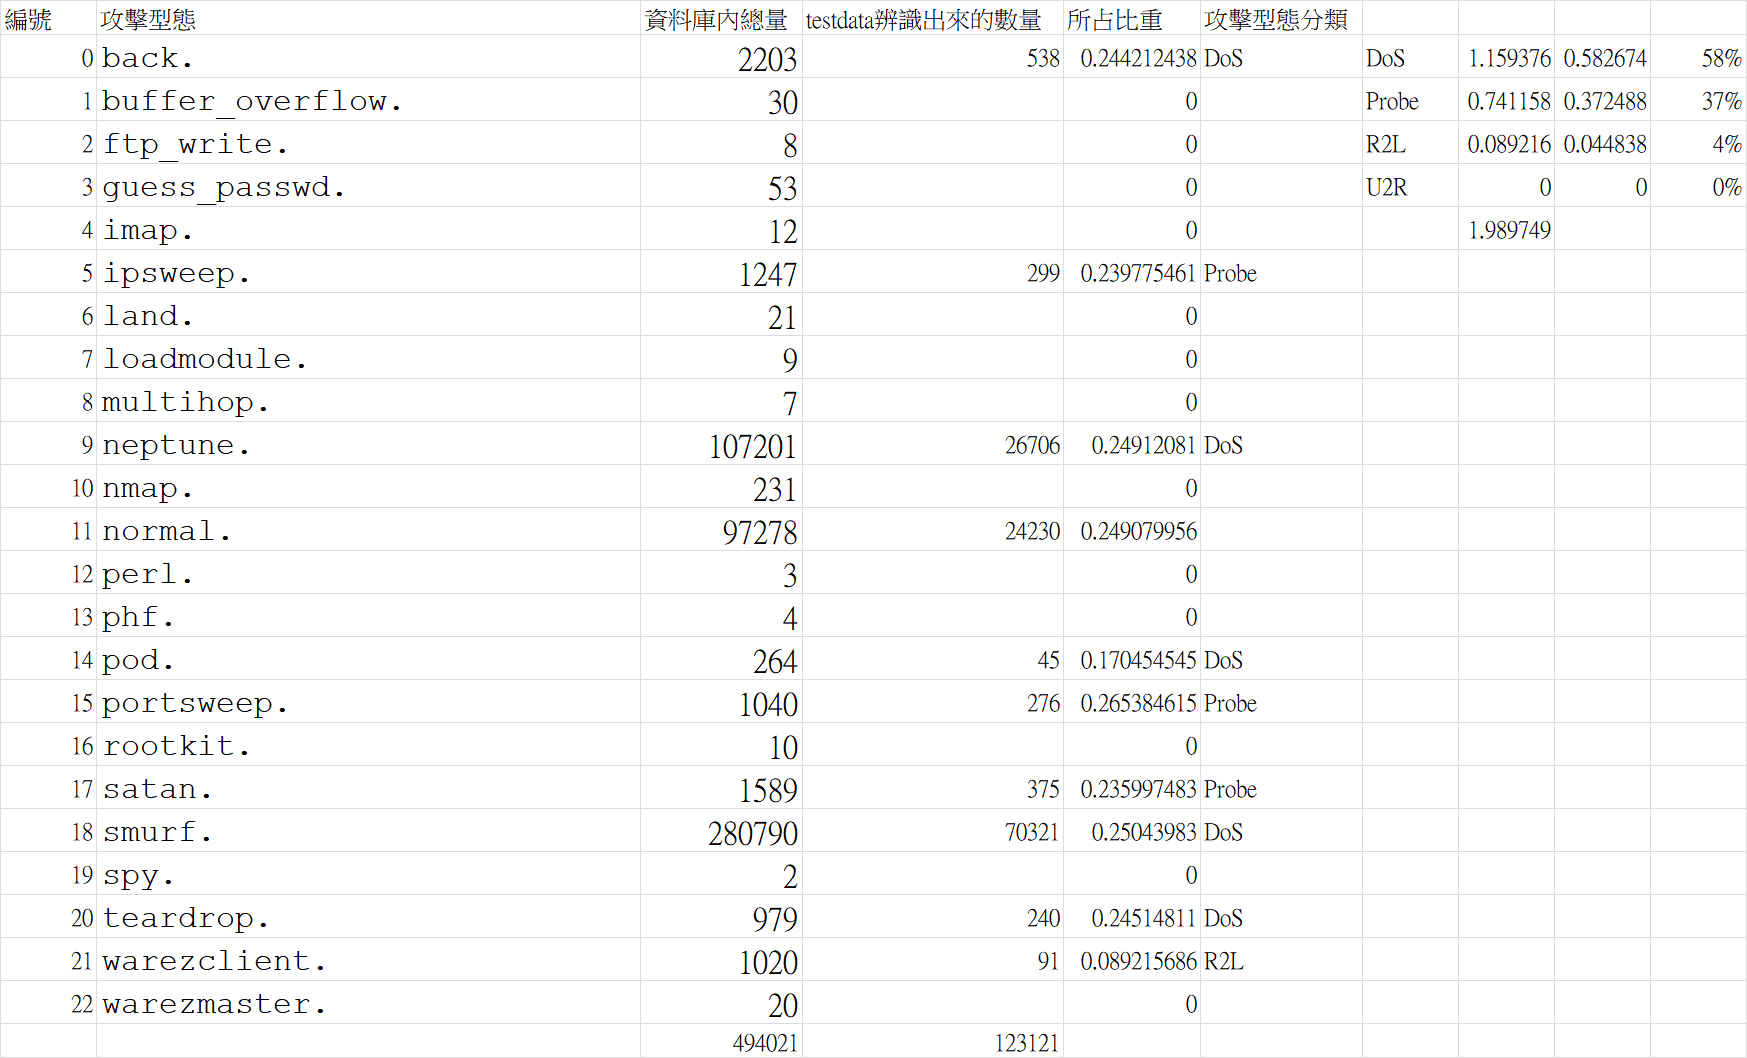

We can now evaluate the neural network. As you can see, the neural network achieves a 99% accuracy rate.

In [ ]:
# Measure accuracy
pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)
y_eval = np.argmax(y_test,axis=1)
score = metrics.accuracy_score(y_eval, pred)
print("Validation score: {}".format(score))

Validation score: 0.9949800009716128


由上方資料取得
DoS. 58%
Probe. 37%
R2L. 4%
U2R. 0%

假設我方公司現有資訊資產評估為0-100
經過專家系統預設值得到\
防禦手段難度\
DoS. 80\
Probe. 65\
R2L. 55\
U2R. 27\
Normal 5\
防禦資訊資產\
user 25\
software 60\
hardware 85

經資訊資產評估
假定為\
user 70%
software 20%
hardware 10%

資訊資產為25X0.7+60X0.2+85X0.1=17.5+12+8.5=38\
防禦手段難度由前階段所給予值\
80X.58+65X.37+55X.04=46.4+24.05+2.2=72.65


下方導入FuzzyLogic專家系統

In [ ]:
import sys
# 分析攻擊手法總共有DoS Probe R2L U2R Normal，從防禦技術難度去分析 DoS > U2R > R2L > Probe > Normal
# 防禦手法Sophisticated Hardware、Software、User，從難度成本上去分析 SH > S > U

cyber_status_fuzzy_set = ['Normal', 'Probe', 'R2L', 'U2R', 'DoS'] #inpout，針對不同型態的網路問題進行評估
IT_assets_fuzzy_set = ['User', 'Software', 'Hardware'] #input，投入那些技術資產進行防禦手段

sprinkler_duration_fuzzy_set = ['Short', 'Medium', 'Long'] #output, 多久的時間成本，用來解決防禦問題

def main():
  print('')
  print('Input Of Fuzzyfication')
  print('')
  print('請輸入攻擊型態經驗評估值(限定0-100):', end='', flush=True)
  cyber_status = int(73)  #參數由此輸入
  print(cyber_status)
  print('請輸入您投入資訊資本(IT_assets)參數(限定0-100) :', end='', flush=True)
  IT_assets = int(38)   #參數由此輸入
  print(IT_assets)


  rules = parse_kb_file('cyberrule.kb')
  #測試cyber_status是否正確執行
  tmp = cyber_statusFunction(cyber_status)
  hum = IT_assetsFunction(IT_assets)
  print('Output Of Fuzzyfication')
  print(tmp)
  print(hum)
  print('')

  inf = inferred(tmp, hum, rules)
  #print(rules)
  #print(inf)
  #for dt in inf:
  #  print(dt)

  result_rule_min = []

  for dt in inf:
    print(dt[0][0][0][1], dt[0][0][0][2], dt[0][0][1][1], dt[0][0][1][2], dt[1])
    minimum = min(dt[0][0][0][2], dt[0][0][1][2])
    result_rule_min.append([dt[1],minimum])
  print('')

  print(result_rule_min)

  result_rule_max = {}
  for data in result_rule_min:
    if data[0] in result_rule_max:
      result_rule_max[data[0]].add(data[1])
    else:
      result_rule_max[data[0]] = set([data[1]])

  output_inference = []
  for key, value in result_rule_max.items():
    output_inference.append([key, max(value)])

  print('')
  print('Output Inference is', output_inference)
  print('')

  print('Deffuzzyfication')
  finalValue = defuzzyfication(output_inference)

  print('Hours', finalValue)


def defuzzyfication(input):
# 這裡的參數決定時間長短
  result = float(0)
  x1_short = 1
  x2_short = 24
  coeficien_short = float(0)

  x1_medium = 12
  x2_medium = 72
  coeficien_medium = float(0)

  x1_long = 24
  x2_long = 168
  coeficien_long = float(0)

  _short_numerator = float(0) #計時器
  _medium_numerator = float(0) #計時器
  _long_numerator = float(0)  #計時器

  _short_denomiantor = float(0) #分母
  _medium_denomiantor = float(0) #分母
  _long_denomiantor = float(0)  #分母

  for data in input:
    if data[0] == 'Short':
      coeficien_short = data[1]
    if data[0] == 'Medium':
      coeficien_medium = data[1]
    if data[0] == 'Long':
      coeficien_long = data[1]

  if coeficien_short != float(0) and coeficien_medium != float(0) and coeficien_long == float(0):
    x_start_short = x1_short
    x_end_short = x1_medium + 1 #should be plus 1

    x_start_medium = x2_short
    x_end_medium = x1_long + 1 #should be plus 1

    for i in range(x_start_short, x_end_short):
      _short_numerator += i * coeficien_short
      _short_denomiantor += coeficien_short

    for i in range(x_start_medium, x_end_medium):
      _medium_numerator += i * coeficien_medium
      _medium_denomiantor += coeficien_medium

    result = (_medium_numerator + _short_numerator)/ (_medium_denomiantor + _short_denomiantor)

    #============================================
  if coeficien_short == float(0) and coeficien_medium != float(0) and coeficien_long != float(0):


    x_start_medium = x2_short
    x_end_medium = x1_long + 1 #should be plus 1

    x_start_long = x2_medium
    x_end_long = x2_long + 1 #should be plus 1


    for i in range(x_start_medium, x_end_medium):
      _medium_numerator += i * coeficien_medium
      _medium_denomiantor += coeficien_medium

    for i in range(x_start_long, x_end_long):
      _long_numerator += i * coeficien_long
      _long_denomiantor += coeficien_long

    result = (_medium_numerator + _long_numerator)/ (_medium_denomiantor + _long_denomiantor)

    #============================================
  if coeficien_short != float(0) and coeficien_medium != float(0) and coeficien_long != float(0):

    x_start_short = x1_short
    x_end_short = x1_medium + 1 #should be plus 1

    x_start_medium = x2_short
    x_end_medium = x1_long + 1 #should be plus 1

    x_start_long = x2_medium
    x_end_long = x2_long + 1 #should be plus 1

    for i in range(x_start_short, x_end_short):
      _short_numerator += i * coeficien_short
      _short_denomiantor += coeficien_short

    for i in range(x_start_medium, x_end_medium):
      _medium_numerator += i * coeficien_medium
      _medium_denomiantor += coeficien_medium

    for i in range(x_start_long, x_end_long):
      _long_numerator += i * coeficien_long
      _long_denomiantor += coeficien_long

    result = (_short_numerator + _medium_numerator + _long_numerator)/ (_short_denomiantor + _medium_denomiantor + _long_denomiantor)

  if coeficien_short != float(0) and coeficien_medium == float(0) and coeficien_long == float(0):
    x_start_short = x1_short
    x_end_short = x1_medium + 1 #should be plus 1

    for i in range(x_start_short, x_end_short):
      _short_numerator += i * coeficien_short
      _short_denomiantor += coeficien_short

    result = (_short_numerator) / (_short_denomiantor)

   #=========================
  if coeficien_short == float(0) and coeficien_medium != float(0) and coeficien_long == float(0):
    x_start_medium = x2_short
    x_end_medium = x1_long + 1 #should be plus 1

    for i in range(x_start_medium, x_end_medium):
      _medium_numerator += i * coeficien_medium
      _medium_denomiantor += coeficien_medium

    result = (_medium_numerator) / (_medium_denomiantor)

     #=========================
  if coeficien_short == float(0) and coeficien_medium == float(0) and coeficien_long != float(0):
    x_start_long = x2_medium
    x_end_long = x2_long + 1 #should be plus 1

    for i in range(x_start_long, x_end_long):
      _long_numerator += i * coeficien_long
      _long_denomiantor += coeficien_long

    result = (_long_numerator) / (_long_denomiantor)


  return result

def inferred(fuzzification_temp, fuzzification_hum, fuzzyfication_rule):
  agenda = []
  possibility = []

  for dt in fuzzification_temp:
    agenda.append(dt)
  for dt in fuzzification_hum:
    agenda.append(dt)

  while agenda:
    item = agenda.pop(0)
    for rule in fuzzyfication_rule:
      for j, premise in enumerate(rule[0]):
        if premise == item[0]:
          rule[0][j] = [True, rule[0][j], item[1]]
      if check_hypothesis(rule[0]):
        conclusion = rule[1]
        possibility.append(rule)
        agenda.append(conclusion)
        rule[0] = [rule[0],'processed']


  return possibility

def check_hypothesis(hypothesis):
  for entry in hypothesis:
    if entry[0] != True:
      return False
  return True


def cyber_statusFunction(input):

  amin = 0
  amax = 10

  bmin = 5
  bmax = 50

  cmin = 40
  cmax = 70

  dmin = 50
  dmax = 80

  emin = 60
  emax = 100
  linguistik_cyber_status = []
  if input >= amin and input <= amax:
    linguistik_cyber_status.append(cyber_status_fuzzy_set[0]) #Normal
  if input >= bmin and input <= bmax:
    linguistik_cyber_status.append(cyber_status_fuzzy_set[1]) #Probe
  if input >= cmin and input <= cmax:
    linguistik_cyber_status.append(cyber_status_fuzzy_set[2]) #R2L
  if input >= dmin and input <= dmax:
    linguistik_cyber_status.append(cyber_status_fuzzy_set[3]) #U2R
  if input >= emin and input <= emax:
    linguistik_cyber_status.append(cyber_status_fuzzy_set[4]) #DoS

  #=======================================

  value_temp = []
  if len(linguistik_cyber_status) > 1 :
    if linguistik_cyber_status[0] == cyber_status_fuzzy_set[0] and linguistik_cyber_status[1] == cyber_status_fuzzy_set[1]: #Between Cold and Cool
      #Cold
      cold = -(input - amax)/(amax - bmin)
      value_temp.append([linguistik_cyber_status[0],cold])
      #Cool
      cool = (input - bmin)/(amax - bmin)
      value_temp.append([linguistik_cyber_status[1],cool])
    elif linguistik_cyber_status[0] == cyber_status_fuzzy_set[1] and linguistik_cyber_status[1] == cyber_status_fuzzy_set[2]: #Between Cool and Normal
      #Cool
      cool = -(input - bmax)/(bmax - cmin)
      value_temp.append([linguistik_cyber_status[0],cool])
      #Normal
      normal = (input - cmin)/(bmax - cmin)
      value_temp.append([linguistik_cyber_status[1],normal])
    elif linguistik_cyber_status[0] == cyber_status_fuzzy_set[2] and linguistik_cyber_status[1] == cyber_status_fuzzy_set[3]: #Between Normal and Warm
      #Normal
      normal = -(input - cmax)/(cmax - dmin)
      value_temp.append([linguistik_cyber_status[0],normal])
      #Warm
      warm = (input - dmin)/(cmax - dmin)
      value_temp.append([linguistik_cyber_status[1],warm])
    elif linguistik_cyber_status[0] == cyber_status_fuzzy_set[3] and linguistik_cyber_status[1] == cyber_status_fuzzy_set[4]: #Between Warm and Hot
      #Warm
      warm = -(input - dmax)/(dmax - emin)
      value_temp.append([linguistik_cyber_status[0],warm])
      #Hot
      hot = (input - emin)/(dmax - emin)
      value_temp.append([linguistik_cyber_status[1],hot])
  else:
    value_temp.append([linguistik_cyber_status[0],1])
  return value_temp

def IT_assetsFunction(input):
  fmin = 0
  fmax = 50

  gmin = 40
  gmax = 80

  hmin = 70
  hmax = 100
  linguistik_IT_assets = []
  if input >= fmin and input <= fmax:
    linguistik_IT_assets.append(IT_assets_fuzzy_set[0])
  if input >= gmin and input <= gmax:
    linguistik_IT_assets.append(IT_assets_fuzzy_set[1])
  if input >= hmin and input <= hmax:
    linguistik_IT_assets.append(IT_assets_fuzzy_set[2])

  #============================================

  value_hum = []

  if len(linguistik_IT_assets) > 1:
    if linguistik_IT_assets[0] == IT_assets_fuzzy_set[0] and linguistik_IT_assets[1] == IT_assets_fuzzy_set[1]:
      dry = -(input - fmax)/(fmax - gmin)
      value_hum.append([linguistik_IT_assets[0],dry])
      moist = (input - gmin)/(fmax - gmin)
      value_hum.append([linguistik_IT_assets[1],moist])
    elif linguistik_IT_assets[0] == IT_assets_fuzzy_set[1] and linguistik_IT_assets[1] == IT_assets_fuzzy_set[2]:
      moist = -(input - gmax)/(gmax - hmin)
      value_hum.append([linguistik_IT_assets[0],moist])
      wet = (input - hmin)/(gmax - hmin)
      value_hum.append([linguistik_IT_assets[1],wet])
  else:
    value_hum.append([linguistik_IT_assets[0],1])
  return value_hum

def parse_kb_file(filename):
  kb_file = open(filename, 'r')  #'rU' is smart about line-endings ，因為版本問題建議改成'r'
  kb_rules = []           #to hold the list of rules

  for line in kb_file:      #read the non-commented lines
    if not line.startswith('#') and line != '\n':
      kb_rules.append(split_and_build_literals(line.strip()))

  kb_file.close()
  return kb_rules

def split_and_build_literals(line):
  rules = []
  #Splite the line of literals
  literals = line.split(' ')
  hypothesis = []
  while len(literals) > 1:
    hypothesis.append(literals.pop(0))
  rules.append(hypothesis)
  rules.append(literals.pop(0))
  return rules

if __name__ == '__main__':
  main()


Input Of Fuzzyfication

請輸入攻擊型態經驗評估值(限定0-100):73
請輸入您投入資訊資本(IT_assets)參數(限定0-100) :38
Output Of Fuzzyfication
[['U2R', 0.35], ['DoS', 0.65]]
[['User', 1]]

U2R 0.35 User 1 Long
DoS 0.65 User 1 Long

[['Long', 0.35], ['Long', 0.65]]

Output Inference is [['Long', 0.65]]

Deffuzzyfication
Hours 120.00000000000018


將下列文字存成 rule.kb  檔案(請使用編輯狀態複製  不要直接複製)
再運用下方上傳程式將檔案傳到本程式資料夾

Cold Dry Long
Cold Moist Long
Cold Wet Short

Cool Dry Long
Cool Moist Medium
Cool Wet Short

Normal Dry Long
Normal Moist Medium
Normal Wet Short

Warm Dry Long
Warm Moist Medium
Warm Wet Short

Hot Dry Long
Hot Moist Medium
Hot Wet Short

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cyberrule.kb to cyberrule.kb


In [ ]:
# import pandas as pd
# import numpy as np

# y_test = np.array(list(map(lambda x: text[x], y_test)))
# y_predict = np.array(list(map(lambda x: text[x], y_predict)))
# df = pd.DataFrame({'y_Actual': y_test, 'y_Predicted': y_predict})
# pd.crosstab(df['y_Actual'], df['y_Predicted'], rownames=['Actual'], colnames=['Predicted'])